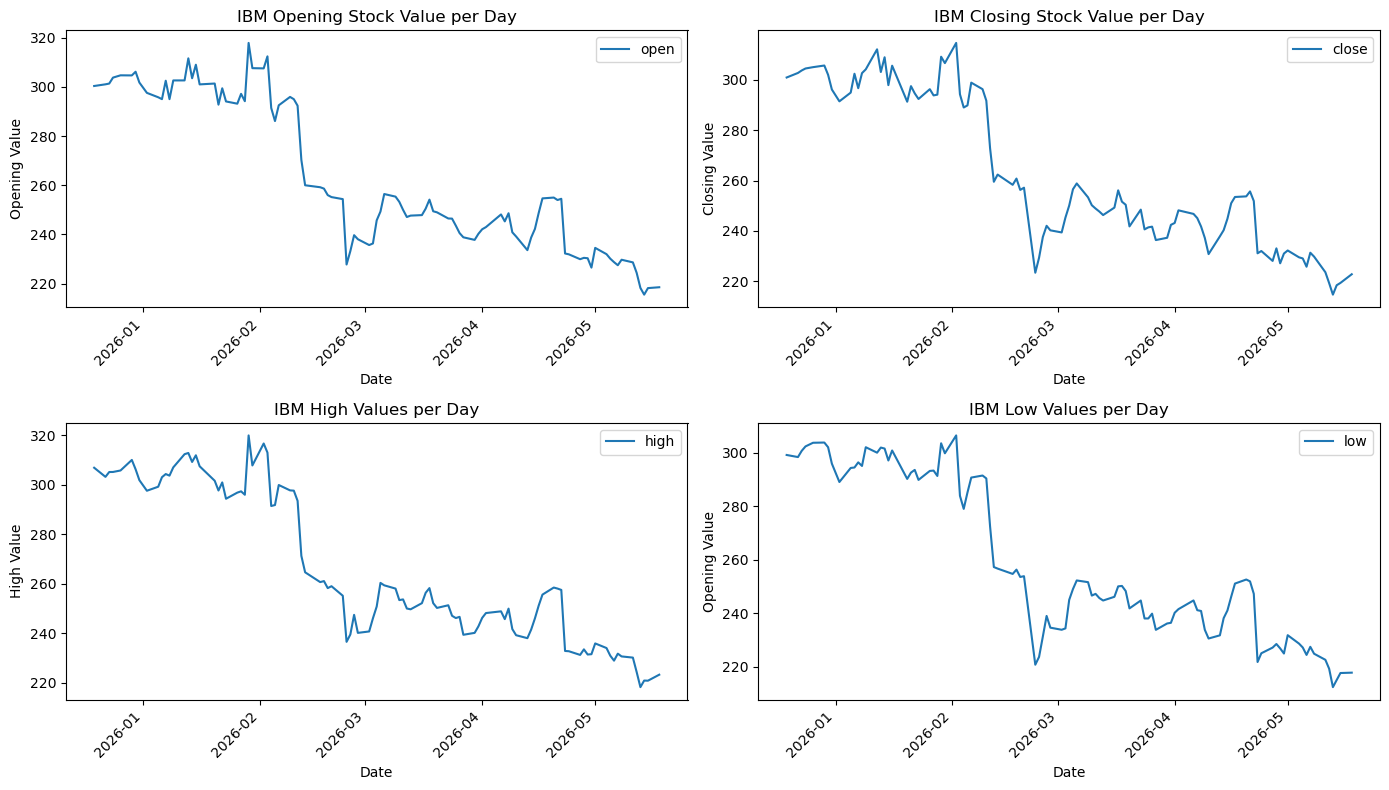

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows = 2,ncols = 2, figsize=(14,8))

conn = sqlite3.connect("StockData.db")
data = pd.read_sql_query("SELECT * FROM IBM_Stock_Data", conn, parse_dates=["date"])

data.plot(
    ax = ax[0,0],
    x = "date",
    y = "open",
    kind = "line",
    xlabel = "Date",
    ylabel = "Opening Value",
    title = "IBM Opening Stock Value per Day"
)
data.plot(
    ax = ax[0,1],
    x = "date",
    y = "close",
    kind = "line",
    xlabel = "Date",
    ylabel = "Closing Value",
    title = "IBM Closing Stock Value per Day"
)
data.plot(
    ax = ax[1,0],
    x = "date",
    y = "high",
    kind = "line",
    xlabel = "Date",
    ylabel = "High Value",
    title = "IBM High Values per Day"
)
data.plot(
    ax = ax[1,1],
    x = "date",
    y = "low",
    kind = "line",
    xlabel = "Date",
    ylabel = "Opening Value",
    title = "IBM Low Values per Day"
)

for axes in ax.flat:
    axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Daily Return'}, xlabel='Date', ylabel='Daily Return'>

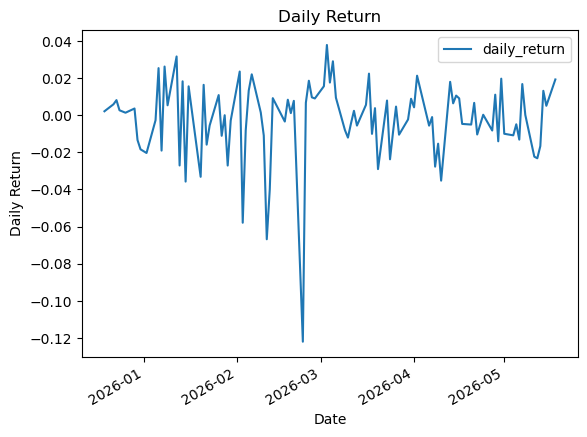

In [5]:
data["daily_return"] = (data["close"] - data["open"]) / data["open"]
data.plot(
    x = "date",
    y = "daily_return",
    xlabel = "Date",
    ylabel = "Daily Return",
    title = "Daily Return"
)



In [6]:
#Moving average of true ranges over 14 day period
#True range Greatest of these 
# Current High minus Current Low: The absolute size of the current period's trading range.
# Absolute Value of Current High minus Previous Close: Accounts for a gap up.
# Absolute Value of Previous Close minus Current Low: Accounts for a gap down

#True Range Calc
curr_high = data["high"].iloc[-1]
curr_low = data["low"].iloc[-1]
prev_close = data["close"].iloc[-2]

high_low = curr_high - curr_low
high_close = curr_high - prev_close
high_low = curr_low - prev_close

true_range = max(high_low,high_close,high_low).round(2)

#Simple Moving Average Calculations
period = 14
close_price_sum = 0
for i in range(period):
    close_price_sum += data["close"].iloc[i-15]
simple_moving_average = (close_price_sum / period).round(2)


#Average True Range
true_range_sum = 0
for i in range(period):
    curr_high = data["high"].iloc[i - 15]
    curr_low = data["low"].iloc[i-15]
    prev_close = data["close"].iloc[i-16]

    high_low = curr_high - curr_low
    high_close = curr_high - prev_close
    high_low = curr_low - prev_close

    true_range_sum += max(high_low,high_close,high_low)
average_true_range = (true_range_sum / period).round(2)

#Worst Trading Day
worst_day = data.loc[data["close"].idxmin()]
worst_day["date"] = worst_day["date"].date()

#Best Trading Day
best_day =  data.loc[data["close"].idxmax()]
best_day["date"] = best_day["date"].date()

#Average Daily Return
avg_daily_return = data["daily_return"].mean()

print("KPIs")
print("Simple Moving Average (14 Day Period):", simple_moving_average)
print("True Range:",true_range)
print("Average True Range (14 Day Period): ", average_true_range)
print("Average Daily Return:", avg_daily_return)
print("Best Trading Day:\n", best_day.to_string())
print("Worst Trading Day:\n", worst_day.to_string())





KPIs
Simple Moving Average (14 Day Period): 225.98
True Range: 4.03
Average True Range (14 Day Period):  2.26
Average Daily Return: -0.0025646401986522517
Best Trading Day:
 date            2026-02-02
open                307.51
high                316.64
low                 306.41
close               314.73
volume             4581189
daily_return      0.023479
Worst Trading Day:
 date            2026-05-13
open                218.27
high                218.31
low                 212.34
close               214.64
volume             8361214
daily_return     -0.016631
